# wczytanie bibliotek


In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_score
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

base_path = Path('data')

# wczytanie danych

In [3]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')

Na podstawie przeprowadzonej EDA wiemy, że zmienne Sex oraz Pclass wykazują silną zależność ze zmienną docelową Survived

# przygotowanie danych

Ze zmiennej Name wyodrębniam nową kolumnę "Title" - tytuł danej osoby, nastepnie usuwam zmienne Name oraz Ticket, które nie przydadzą się do budowy modelu oraz Cabin ze względu na dużą liczbę braków danych


In [4]:
# feature engineering
def feature_engineering(df):
    df = df.copy()
    df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
    rare_titles = ["Lady", "Countess", "Capt", "Col", "Don", "Dr", "Major", "Rev", "Sir", "Jonkheer", "Dona"]
    df["Title"] = df["Title"].replace(rare_titles, "Rare")
    df["Title"] = df["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1 # liczba członków rodziny na pokładzie
    df["IsChild"] = (df["Age"] < 18).astype(int) # czy pasażer jest dzieckiem
    df = df.drop(columns=["Name", "Ticket", "Cabin"])
    return df

titanic_df = feature_engineering(titanic_df)

targetowaną kolumną jest survived

In [5]:
X = titanic_df.drop(columns="Survived")
y = titanic_df["Survived"]

dzielimy zbiór na testowy i treningowy

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [7]:
numeric_features = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "IsChild"
]

categorical_features = [
    "Pclass",
    "Sex",
    "Embarked",
    "Title"
]


będziemy uzupełniać wartości brakujące medianą lub dominantą

In [8]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


kodowanie zmiennych

In [9]:
preprocessor = ColumnTransformer([
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features)
])

In [10]:
def evaluate_model(model, X_train, X_test, y_train, y_test): # funkcja do oceny modelu, przyda się do końcowego porównania
  model.fit(X_train, y_train)
  y_train_pred = model.predict(X_train)
  y_test_pred = model.predict(X_test)
  results = { "Train Accuracy": accuracy_score(y_train, y_train_pred),
             "Test Accuracy": accuracy_score(y_test, y_test_pred),
              "Train Precision": precision_score(y_train, y_train_pred, zero_division=0),
              "Test Precision": precision_score(y_test, y_test_pred, zero_division=0),
              "Train Recall": recall_score(y_train, y_train_pred, zero_division=0),
              "Test Recall": recall_score(y_test, y_test_pred, zero_division=0),
              "Train F1": f1_score(y_train, y_train_pred, zero_division=0),
              "Test F1": f1_score(y_test, y_test_pred, zero_division=0) }
  return results

# dummy classifier

jako bazowy klasyfikator wykorzystamy dummy classifier, do niego będziemy porównywać wyniki otrzymane przez nasze modele

In [11]:
dummy = DummyClassifier(strategy="most_frequent", random_state=42)

dummy_results = evaluate_model( dummy, X_train, X_test, y_train, y_test )

dummy_train_pred = dummy.predict(X_train)
dummy_test_pred = dummy.predict(X_test)

In [12]:
print("wyniki dummy na zbiorze treningowym")
print(classification_report(y_train, dummy_train_pred, zero_division=0))

print("wyniki dummy na zbiorze testowym")
print(classification_report(y_test, dummy_test_pred, zero_division=0))

print("macierz pomyłek dummy na zbiorze testowym")
print(confusion_matrix(y_test, dummy_test_pred))

wyniki dummy na zbiorze treningowym
              precision    recall  f1-score   support

           0       0.62      1.00      0.76       439
           1       0.00      0.00      0.00       273

    accuracy                           0.62       712
   macro avg       0.31      0.50      0.38       712
weighted avg       0.38      0.62      0.47       712

wyniki dummy na zbiorze testowym
              precision    recall  f1-score   support

           0       0.61      1.00      0.76       110
           1       0.00      0.00      0.00        69

    accuracy                           0.61       179
   macro avg       0.31      0.50      0.38       179
weighted avg       0.38      0.61      0.47       179

macierz pomyłek dummy na zbiorze testowym
[[110   0]
 [ 69   0]]


Do oceny modeli będziemy skupiać się na metryce f1, bo uwzględnia ona jednocześnie zarówno precision jak i recall. Dodatkowo zbadamy też accuracy - dokładność klasyfikacji

# drzewo klasyfikacyjne

Najpierw budujemy model drzewa klasyfikacyjnego z max_depth=3. Jako schemat oceny wykorzystamy 5 fold crossvalidation

In [13]:
tree= Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=3,
        random_state=42
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42)

wyniki = cross_val_score(
    tree,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print("Wyniki CV F1:", wyniki)
print(f"Średnia: {wyniki.mean():.3f} "
    f"Odchylenie: {wyniki.std():.3f}")

tree_results = evaluate_model(tree, X_train, X_test, y_train, y_test)
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

print("wyniki drzewa klasyfikacyjnego na zbiorze treningowym:")
print(classification_report(y_train, y_train_pred))
print(confusion_matrix(y_train, y_train_pred))

print("wyniki drzewa klasyfikacyjnego na zbiorze testowym:")
print(classification_report(y_test, y_test_pred))
print(confusion_matrix(y_test, y_test_pred))

Wyniki CV F1: [0.76785714 0.71287129 0.8490566  0.74074074 0.76      ]
Średnia: 0.766 Odchylenie: 0.046
wyniki drzewa klasyfikacyjnego na zbiorze treningowym:
              precision    recall  f1-score   support

           0       0.86      0.89      0.87       439
           1       0.81      0.76      0.78       273

    accuracy                           0.84       712
   macro avg       0.83      0.82      0.83       712
weighted avg       0.84      0.84      0.84       712

[[390  49]
 [ 66 207]]
wyniki drzewa klasyfikacyjnego na zbiorze testowym:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.80      0.74      0.77        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.83       179

[[97 13]
 [18 51]]


Wyniki na zbiorze treningowym i testowym są do siebie mocno zbliżone. oznacza to, że raczej nie doszło do overfittingu

## strojenie hiperparametrów dla drzewa

In [14]:
# siatka hiperparametrów
siatka_tree = {
    "classifier__max_depth": [1, 2, 3, 4, 5, 7, None],
    "classifier__min_samples_split": [2, 5, 10, 20, 30],
    "classifier__min_samples_leaf": [1, 2, 5, 10],
    "classifier__criterion": ["gini", "entropy"]
}
tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42
    ))
])

tree_search = GridSearchCV(
    estimator=tree_pipeline,
    param_grid=siatka_tree,
    cv=cv,
    scoring="f1",
    return_train_score=True
)

tree_search.fit(
    X_train,
    y_train
)

print("najlepsze ustawienia:", tree_search.best_params_)
print("najlepszy wynik kroswalidacji f1:", round(tree_search.best_score_, 3))

najlepsze ustawienia: {'classifier__criterion': 'entropy', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 20}
najlepszy wynik kroswalidacji f1: 0.774


In [15]:
tabela_tree = pd.DataFrame(tree_search.cv_results_)

tabela_tree = tabela_tree[
    [
        "param_classifier__max_depth",
        "param_classifier__min_samples_split",
        "param_classifier__min_samples_leaf",
        "param_classifier__criterion",
        "mean_train_score",
        "mean_test_score",
        "std_test_score"
    ]].rename(columns={
    "param_classifier__max_depth": "max_depth",
    "param_classifier__min_samples_split": "min_samples_split",
    "param_classifier__min_samples_leaf": "min_samples_leaf",
    "param_classifier__criterion": "criterion"
})

tabela_tree = tabela_tree.sort_values("mean_test_score", ascending=False)
tabela_tree.head(10)

,max_depth,min_samples_split,min_samples_leaf,criterion,mean_train_score,mean_test_score,std_test_score
273,None,20,5,entropy,0.828563,0.773583,0.055106
48,3,20,2,gini,0.774149,0.767220,0.044339
43,3,20,1,gini,0.774149,0.767220,0.044339
272,None,10,5,entropy,0.856873,0.767119,0.037019
271,None,5,5,entropy,0.856873,0.767119,0.037019
270,None,2,5,entropy,0.856873,0.767119,0.037019
42,3,10,1,gini,0.775634,0.766105,0.045604
40,3,2,1,gini,0.775634,0.766105,0.045604
47,3,10,2,gini,0.775634,0.766105,0.045604
46,3,5,2,gini,0.775634,0.766105,0.045604


Najlepszy średni wynik kroswalidacji f1 równy ok. 77% uzyskujemy dla parametrów: 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 20. Jednocześnie odchylenie standardowe wyników pomiędzy foldami wynosi ok. 0.055. Dla innych kombinacji, np. przy min_samples_split = 2, uzyskujemy bardzo podobne średnie wyniki przy mniejszym odchyleniu standardowym.

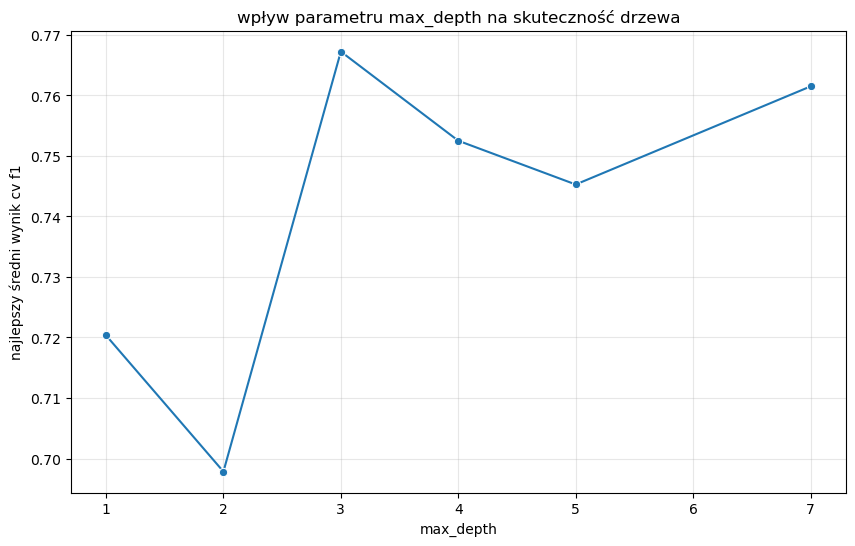

In [16]:
depth_results = (tabela_tree.groupby("max_depth")["mean_test_score"].max().reset_index())

plt.figure(figsize=(10, 6))
sns.lineplot(data=depth_results, x="max_depth", y="mean_test_score", marker="o")
plt.xlabel("max_depth")
plt.ylabel("najlepszy średni wynik cv f1")
plt.title("wpływ parametru max_depth na skuteczność drzewa")
plt.grid(alpha=0.3)
plt.show()

Widzimy, że dalsze zwiększanie głębokości drzewa nie poprawia już najlepszego średniego wyniku cv f1. Najlepsza kombinacja hiperparametrów uzyskana podczas GridSearchCV wykorzystuje jednak max_depth=None.

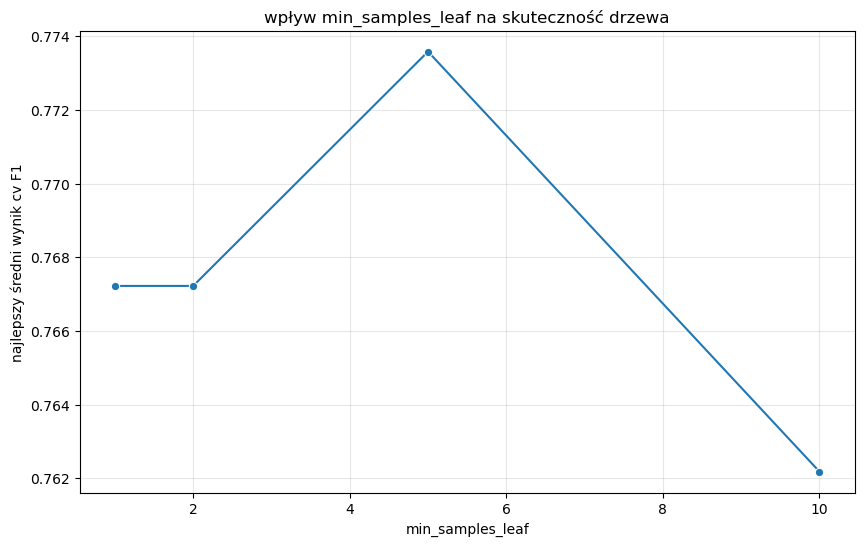

In [17]:
leaf_results = (tabela_tree.groupby("min_samples_leaf")["mean_test_score"].max().reset_index())

plt.figure(figsize=(10, 6))
sns.lineplot(data=leaf_results, x="min_samples_leaf", y="mean_test_score", marker="o")
plt.xlabel("min_samples_leaf")
plt.ylabel("najlepszy średni wynik cv F1")
plt.title("wpływ min_samples_leaf na skuteczność drzewa")
plt.grid(alpha=0.3)
plt.show()

Najlepszy średni wynik f1 osiąga maksimum w 5, a potem maleje w badanym przez nas zakresie

Teraz budujemy drzewo klasyfikacyjne z optymalnymi parametrami

In [18]:
best_tree = tree_search.best_estimator_
tree_train_pred = best_tree.predict(X_train)
tree_test_pred = best_tree.predict(X_test)
best_tree_results = evaluate_model(best_tree, X_train, X_test, y_train, y_test)

In [19]:
print("wyniki drzewa na zbiorze treningowym")
print(classification_report(y_train,tree_train_pred))

print("wyniki drzewa na zbiorze testowym")
print(classification_report(y_test, tree_test_pred))

print("macierz pomyłek na zbiorze testowym")
print(confusion_matrix(y_test, tree_test_pred))

wyniki drzewa na zbiorze treningowym
              precision    recall  f1-score   support

           0       0.86      0.96      0.91       439
           1       0.92      0.76      0.83       273

    accuracy                           0.88       712
   macro avg       0.89      0.86      0.87       712
weighted avg       0.89      0.88      0.88       712

wyniki drzewa na zbiorze testowym
              precision    recall  f1-score   support

           0       0.79      0.91      0.85       110
           1       0.81      0.62      0.70        69

    accuracy                           0.80       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.80      0.80      0.79       179

macierz pomyłek na zbiorze testowym
[[100  10]
 [ 26  43]]


Model z dobranymi parametrami osiąga skuteczność klasfikacji 88% na zbiorze treningowym, 80% na testowym. Różnica 8 punktów procentowych może oznaczać, że doszło do lekkiego przeuczenia

# kNN

W przypadku algorytmu kNN zastosujemy standaryzację danych, ponieważ dla naszego zbioru danych cechy o dużych zakresach liczbowych (np. Fare) zdominowałyby cechy o małych zakresach (np. Pclass czy Sex)

## kNN i strojenie hiperparametrów

In [25]:
numeric_transformer_knn = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_knn = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_knn = ColumnTransformer([
    ("numeric", numeric_transformer_knn, numeric_features),
    ("categorical", categorical_transformer_knn, categorical_features)
])

knn_pipeline = Pipeline([
    ("preprocessor", preprocessor_knn),
    ("knn", KNeighborsClassifier())
])

# siatka hiperparametrów
siatka_knn = {
    "knn__n_neighbors": range(5, 61),
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2] # p=1 to odległość Manhattan, a p=2 Euclidean
}

knn_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=siatka_knn,
    cv=cv,
    scoring="f1",
    return_train_score=True,
    n_jobs=-1
)

knn_search.fit(X_train, y_train)


print("najlepsze parametry:", knn_search.best_params_)
print("najlepszy wynik CV F1:", round(knn_search.best_score_, 3))

najlepsze parametry: {'knn__n_neighbors': 33, 'knn__p': 1, 'knn__weights': 'uniform'}
najlepszy wynik CV F1: 0.761


c:\Users\kasia\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Najlepszy średni wynik kroswalidacji f1 równy 76.1% dostajemy dla liczby sąsiadów równej 33, odległości manhattan i weights=uniform

In [21]:
knn_tuning = pd.DataFrame(knn_search.cv_results_)

knn_tuning = knn_tuning[ [
    "param_knn__n_neighbors",
    "param_knn__weights",
    "param_knn__p",
    "mean_train_score",
    "mean_test_score",
    "std_test_score" ] ].sort_values( "mean_test_score", ascending=False )

knn_tuning.head(10)


,param_knn__n_neighbors,param_knn__weights,param_knn__p,mean_train_score,mean_test_score,std_test_score
112,33,uniform,1,0.764550,0.761337,0.036544
80,25,uniform,1,0.769149,0.759789,0.044042
32,13,uniform,1,0.790697,0.759091,0.038702
88,27,uniform,1,0.770236,0.758896,0.049980
120,35,uniform,1,0.762332,0.757504,0.035108
72,23,uniform,1,0.767054,0.757108,0.039830
136,39,uniform,1,0.757784,0.756447,0.042603
104,31,uniform,1,0.767684,0.756353,0.048312
96,29,uniform,1,0.770455,0.756278,0.050300
92,28,uniform,1,0.768010,0.754699,0.040264


Ponownie widzimy, że najlepszy wynik kroswalidacji f1 równy ok. 76% uzyskujemy dla k=33 i weights=uniform. Odchylenie standardowe wyników pomiędzy foldami wynosi 0.037, co oznacza że model działa dość stabilnie

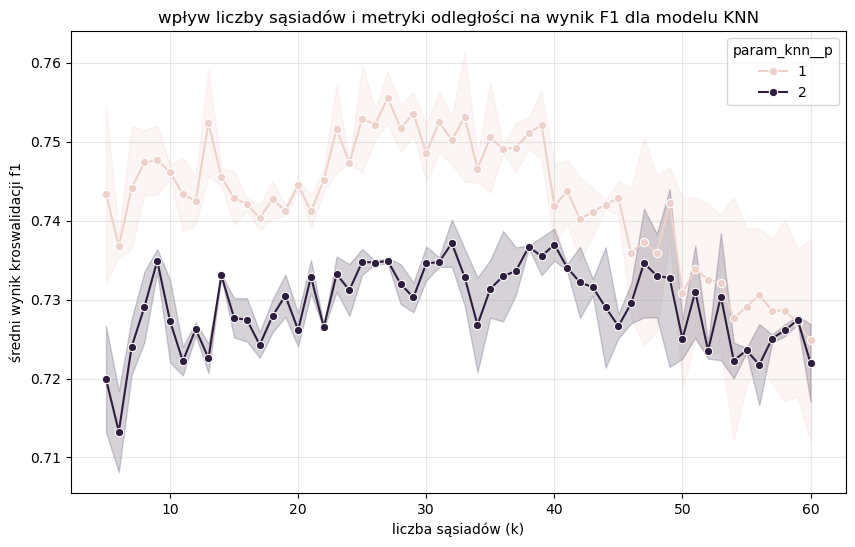

In [22]:
plt.figure(figsize=(10, 6))

sns.lineplot(data=knn_tuning, x="param_knn__n_neighbors", y="mean_test_score", hue="param_knn__p", marker="o")
plt.xlabel("liczba sąsiadów (k)")
plt.ylabel("średni wynik kroswalidacji f1")
plt.title("wpływ liczby sąsiadów i metryki odległości na wynik F1 dla modelu KNN")
plt.grid(alpha=0.3)
plt.show()

Widzimy, że ogólnie lepsze średnie wyniki CV F1 osiągamy dla odległości Manhattan (p=1). Dopiero dla wyższej liczby sąsiadów (ponad 50) wyniki odległości Manhattan zbliżają się do Euklidesowej

In [23]:
best_knn = knn_search.best_estimator_

knn_train_pred = best_knn.predict(X_train)
knn_test_pred = best_knn.predict(X_test)

print("wyniki KNN na zbiorze treningowym:")
print(classification_report(y_train, knn_train_pred))

print("wyniki KNN na zbiorze testowym:")
print(classification_report(y_test, knn_test_pred))

print("macierz pomyłek na zbiorze testowym:")
print(confusion_matrix(y_test, knn_test_pred))
final_knn_results = evaluate_model( best_knn, X_train, X_test, y_train, y_test )

wyniki KNN na zbiorze treningowym:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       439
           1       0.83      0.74      0.78       273

    accuracy                           0.84       712
   macro avg       0.84      0.82      0.83       712
weighted avg       0.84      0.84      0.84       712

wyniki KNN na zbiorze testowym:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86       110
           1       0.82      0.71      0.76        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.82       179

macierz pomyłek na zbiorze testowym:
[[99 11]
 [20 49]]


Model knn z dobranymi optymalnymi parametrami osiąga skuteczność klasyfikacji 84% na zbiorze treningowym, a na testowym 83%. oznacza to, że raczej nie doszło do przeuczenia

# porównanie modeli na zbiorze testowym

In [24]:
comparison = pd.DataFrame([
    {"Model": "Dummy", **dummy_results},
    {"Model": "Classification Tree", **best_tree_results},
    {"Model": "kNN", **final_knn_results}])
print(comparison[["Model",
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1"]])

                 Model  Test Accuracy  Test Precision  Test Recall   Test F1
0                Dummy       0.614525        0.000000     0.000000  0.000000
1  Classification Tree       0.798883        0.811321     0.623188  0.704918
2                  kNN       0.826816        0.816667     0.710145  0.759690


Na zbiorze testowym najlepsze wyniki spośród modeli osiągnął kNN (z dobranymi parametrami k=33, p=1 i weights=uniform), uzyskał on wynik f1 ok.76% oraz accuracy równe ok. 82.7%. kNN osiąga jednak Recall równy ok. 71%, który jest niższy w porównaniu do wyższego Precision równego 81.7%, oznacza to, że model nie wykrywa wszystkich osób, które faktycznie przeżyły. Drzewo klasyfikacyjne osiąga jeszcze niższy Recall niż kNN, przy podobnym precision. Oba modele, drzewo klasyfikacyjne i kNN, osiągnęły znacznie wyższe wyniki niż Dummy Classifier, którego accuracy wynosi ok. 61% (dokładnie tyle, ilu pasażerów zginęło). Jego wynik f1 wynosi 0, bo nigdy nie przewiduje on, że pasażer przeżył.